In [1]:
# test
import pandas as pd
data = pd.read_csv("llm_rag_dataset_6k.csv.csv")
data.columns.tolist()

['sample_id',
 'domain',
 'question',
 'ground_truth_answer',
 'retrieved_context',
 'llm_response_without_rag',
 'llm_response_with_rag',
 'hallucination_label_without_rag',
 'hallucination_label_with_rag',
 'hallucination_type',
 'factual_consistency_score',
 'context_relevance_score',
 'source_support_label',
 'final_target_label']

All expected columns present.
----------------------------------------
--- Dataset Overview ---
Shape: (6000, 14)
Duplicates: 0
Memory Usage: 3.88 MB

--- Missing Value Audit ---
sample_id                          0
domain                             0
question                           0
ground_truth_answer                0
retrieved_context                  0
llm_response_without_rag           0
llm_response_with_rag              0
hallucination_label_without_rag    0
hallucination_label_with_rag       0
hallucination_type                 0
factual_consistency_score          0
context_relevance_score            0
source_support_label               0
final_target_label                 0
dtype: int64

--- Numeric Stability Audit ---

--- Cardinality Audit (Top 5) ---
   sample_id      domain                                           question        ground_truth_answer                                  retrieved_context                  llm_response_without_rag                           

<Figure size 1000x400 with 0 Axes>

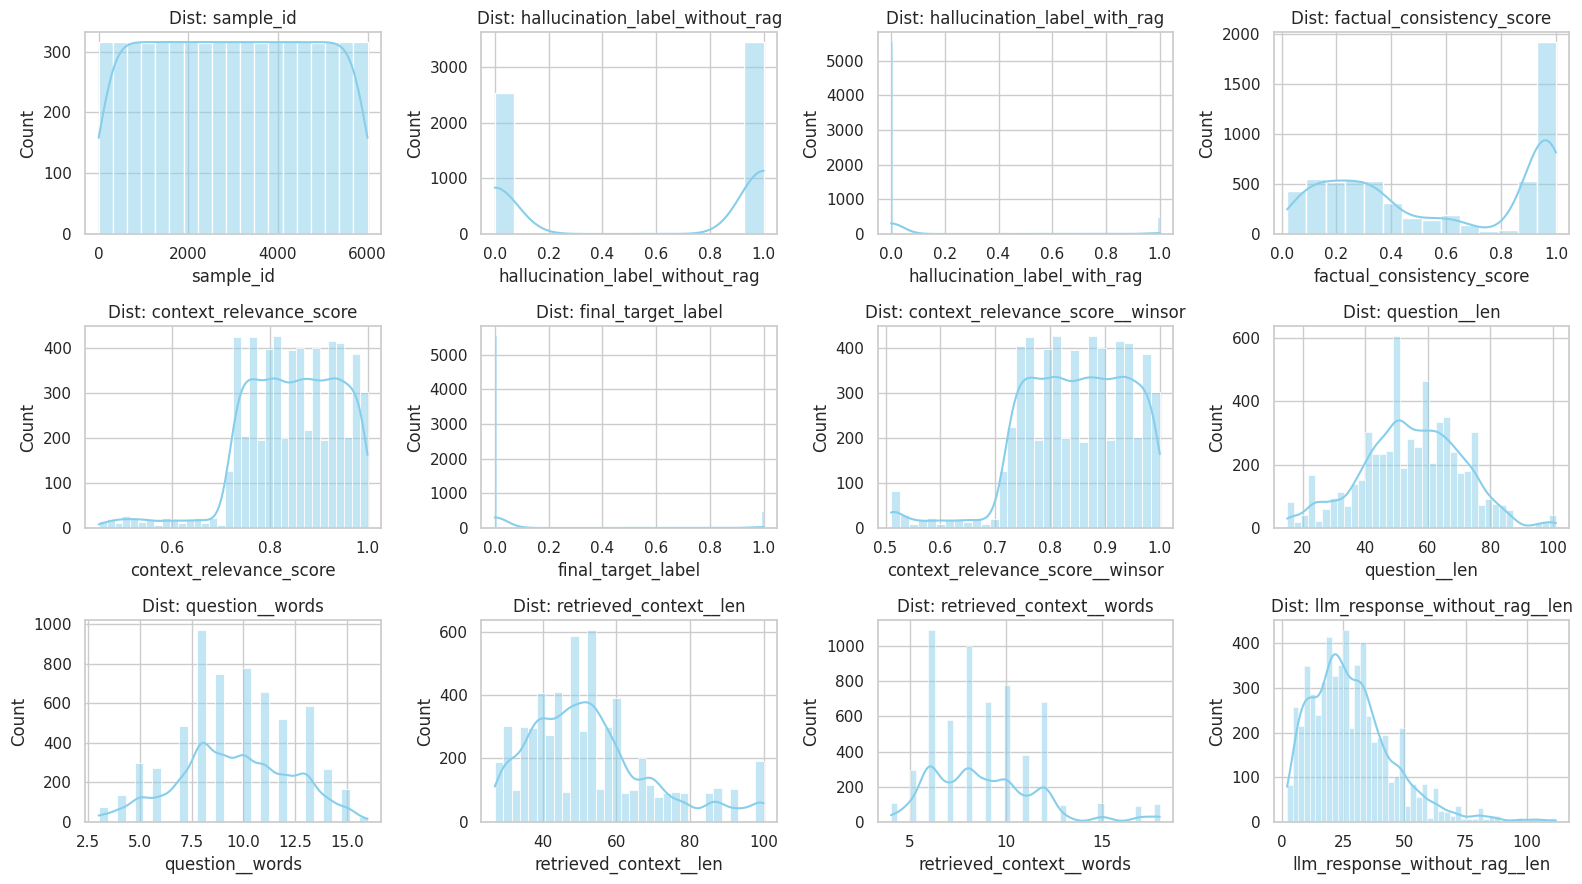

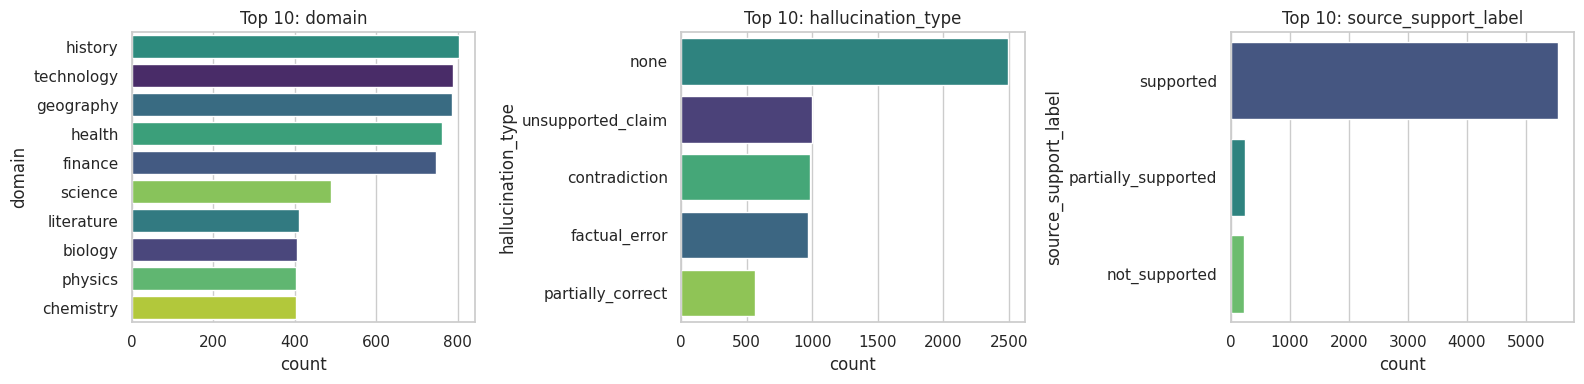

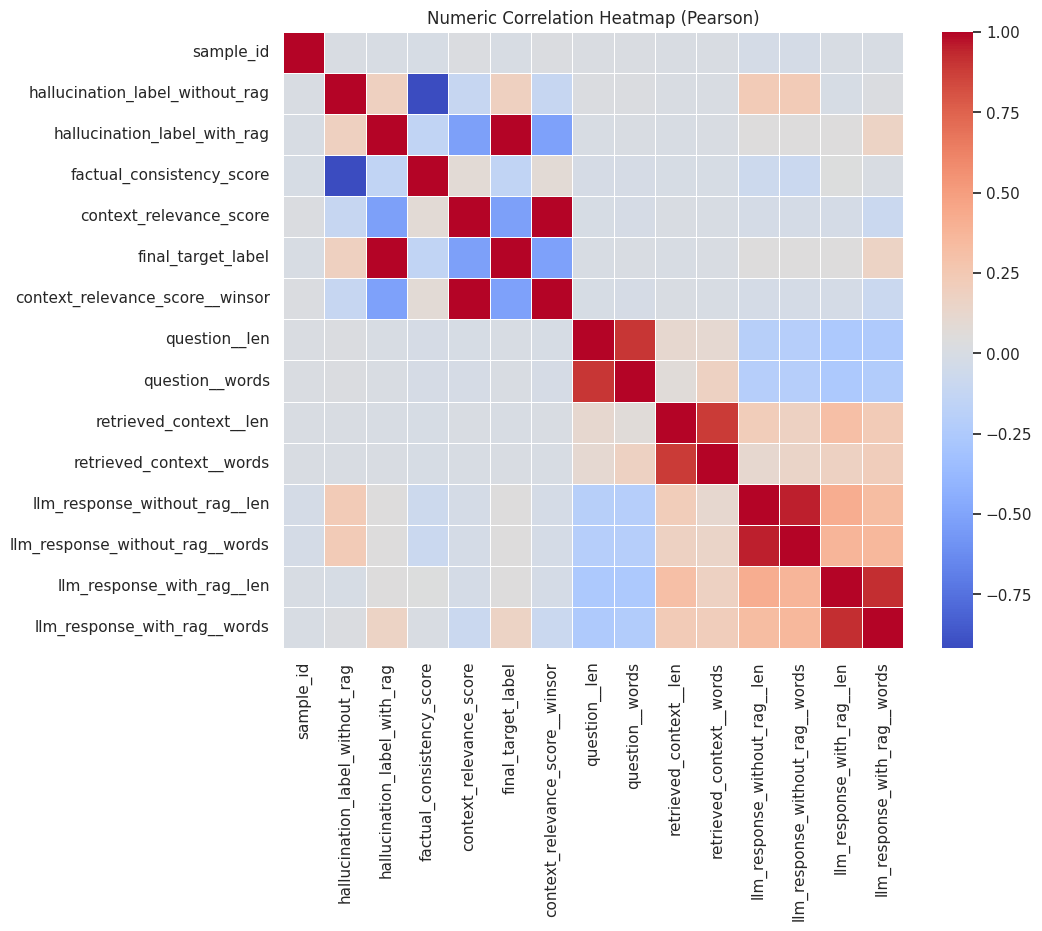


Top Numeric Correlations with final_target_label:
hallucination_label_with_rag      1.0000
final_target_label                1.0000
context_relevance_score           0.5205
context_relevance_score__winsor   0.5155
hallucination_label_without_rag   0.1873
llm_response_with_rag__words      0.1636
Name: final_target_label, dtype: float64

--- Final Quality Summary ---
Original Shape: (6000, 14)
Cleaned Shape: (6000, 23)
Total Missing Values Remaining: 0

--- Processed Data Sample (df_clean) ---
   sample_id      domain                                           question        ground_truth_answer                                  retrieved_context                  llm_response_without_rag                              llm_response_with_rag  hallucination_label_without_rag  hallucination_label_with_rag hallucination_type  factual_consistency_score  context_relevance_score source_support_label  final_target_label  context_relevance_score__winsor  question__len  question__words  retrieved_cont

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# --- A) Imports + Global Config ---
warnings.filterwarnings('ignore')
SEED = 42
DATA_DIR = 'llm_rag_dataset_6k.csv.csv'

np.random.seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style="whitegrid")

# --- Inputs ---

TARGET_COL = 'final_target_label'


def validate_columns(df : pd.DataFrame, expected : list):
    if not expected:
        return
    actual = df.columns.tolist()
    missing = [c for c in expected if c not in actual]
    extra = [c for c in actual if c not in expected]
    if missing: print(f"Missing columns: {missing}")
    if extra: print(f"Extra columns found: {extra}")
    if not missing and not extra: print("All expected columns present.")
    print("-" * 40)

def detect_column_types(df : pd.DataFrame):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    datetime_cols = []
    
    # Simple heuristic for potential datetime strings
    date_regex = r'(\d{4}[-/]\d{2}[-/]\d{2})|(\d{2}[-/]\d{2}[-/]\d{4})'
    for col in categorical_cols:
        sample = df[col].dropna().head(10).astype(str)
        if sample.str.contains(date_regex).any():
            try:
                pd.to_datetime(sample, errors='raise')
                datetime_cols.append(col)
            except:
                pass
    
    # Move detected datetimes from categorical
    categorical_cols = [c for c in categorical_cols if c not in datetime_cols]
    return numeric_cols, categorical_cols, datetime_cols

def audit_data(df : pd.DataFrame):
    print("--- Dataset Overview ---")
    print(f"Shape: {df.shape}")
    print(f"Duplicates: {df.duplicated().sum()}")
    print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    print("\n--- Missing Value Audit ---")
    print(df.isnull().sum()*100)
    
    numeric_cols, categorical_cols, datetime_cols = detect_column_types(df)
    
    print("\n--- Numeric Stability Audit ---")
    for col in numeric_cols:
        inf_count = np.isinf(df[col]).sum()
        var = df[col].var()
        if inf_count > 0 or var < 1e-6:
            print(f"Column '{col}': Infs={inf_count}, Variance={var:.6f} (Low Variance Alert)")
            
    print("\n--- Cardinality Audit (Top 5) ---")
    print(df.head())


def clean_data(df : pd.DataFrame):
    df_clean = df.copy()
    num_cols, cat_cols, dt_cols = detect_column_types(df_clean)
    
    # 1. Standardize text and unify missing tokens
    missing_tokens = ["", "NA", "N/A", "null", "None", "nan", "NaN"]
    for col in cat_cols:
        df_clean[col] = df_clean[col].astype(str).str.strip()
        df_clean[col] = df_clean[col].replace(missing_tokens, np.nan)
        
    # 2. Convert to numeric where possible
    for col in cat_cols:
        # Check if column is mostly numeric-looking
        sample = df_clean[col].dropna().head(20)
        if sample.str.match(r'^-?\d*\.?\d+$').all():
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    # 3. Handle Datetime
    for col in dt_cols:
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')
        
    # Refresh types after conversion
    num_cols, cat_cols, dt_cols = detect_column_types(df_clean)
    
    # 4. Handle Missing (Indicator + Impute)
    for col in num_cols:
        if df_clean[col].isnull().any():
            df_clean[f"{col}__was_missing"] = df_clean[col].isnull().astype(int)
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            
    for col in cat_cols:
        if df_clean[col].isnull().any():
            df_clean[f"{col}__was_missing"] = df_clean[col].isnull().astype(int)
            df_clean[col] = df_clean[col].fillna("Missing")

    # 5. Outliers (Winsorization indicator)
    for col in num_cols:
        if df_clean[col].nunique() > 10:
            q1, q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
            iqr = q3 - q1
            outliers = ((df_clean[col] < (q1 - 1.5 * iqr)) | (df_clean[col] > (q3 + 1.5 * iqr))).sum()
            if outliers > 0:
                lower, upper = df_clean[col].quantile(0.01), df_clean[col].quantile(0.99)
                df_clean[f"{col}__winsor"] = df_clean[col].clip(lower, upper)
    
    # 6. Duplicates
    df_clean = df_clean.drop_duplicates(keep='first')
    
    return df_clean

def feature_engineering(df : pd.DataFrame):
    df_fe = df.copy()
    num_cols, cat_cols, dt_cols = detect_column_types(df_fe)
    
    # Datetime features
    for col in dt_cols:
        try:
            df_fe[f"{col}_year"] = df_fe[col].dt.year
            df_fe[f"{col}_month"] = df_fe[col].dt.month
            df_fe[f"{col}_dayofweek"] = df_fe[col].dt.dayofweek
        except: pass
        
    # Text features (length & word count)
    text_cols = [c for c in cat_cols if df_fe[c].map(lambda x: len(str(x))).mean() > 20]
    for col in text_cols:
        df_fe[f"{col}__len"] = df_fe[col].astype(str).apply(len)
        df_fe[f"{col}__words"] = df_fe[col].astype(str).apply(lambda x: len(x.split()))
        
    return df_fe

def plotting_suite(df : pd.DataFrame, target_col=None):
    num_cols, cat_cols, dt_cols = detect_column_types(df)
    
    # 1. Missingness
    plt.figure(figsize=(10, 4))
    null_pct = df.isnull().mean() * 100
    if null_pct.any():
        null_pct[null_pct > 0].sort_values(ascending=False).head(30).plot(kind='bar', color='salmon')
        plt.title("Missing Values Percentage per Column")
        plt.ylabel("% Missing")
        plt.show()

    # 2. Numeric Distributions (Histograms)
    plot_num = num_cols[:12]
    if plot_num:
        n_rows = (len(plot_num) + 3) // 4
        fig, axes = plt.subplots(n_rows, 4, figsize=(16, 3 * n_rows))
        axes = axes.flatten() # Flatten in case of single row
        for i, col in enumerate(plot_num):
            sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue') #, bins=30
            axes[i].set_title(f"Dist: {col}")
        for j in range(i + 1, len(axes)): fig.delaxes(axes[j]) # Remove unused subplots
        plt.tight_layout()
        plt.show()

    # 3. Categorical Countplots
    plot_cat = [c for c in cat_cols if df[c].nunique() < 50][:6] # Limit to 6 for readability
    if plot_cat:
        n_rows = (len(plot_cat) + 2) // 3
        fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4 * n_rows))
        axes = axes.flatten()
        for i, col in enumerate(plot_cat):
            order = df[col].value_counts().iloc[:10].index
            sns.countplot(y=df[col], order=order, ax=axes[i], hue=df[col], palette='viridis', legend=False)
            axes[i].set_title(f"Top 10: {col}")
        for j in range(i + 1, len(axes)): fig.delaxes(axes[j])
        plt.tight_layout()
        plt.show()

    # 4. Correlation Heatmap
    if len(num_cols) >= 2:
        plt.figure(figsize=(10, 8))
        corr = df[num_cols[:50]].corr()
        sns.heatmap(corr, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
        plt.title("Numeric Correlation Heatmap (Pearson)")
        plt.show()
        
    # 5. Target Analysis
    if target_col and target_col in df.columns:
        if df[target_col].dtype in [np.float64, np.int64]:
            # Numeric Target vs Top features
            top_corr = df[num_cols].corr()[target_col].abs().sort_values(ascending=False).head(6)
            print(f"\nTop Numeric Correlations with {target_col}:\n{top_corr}")
        else:
            # Categorical Target
            plt.figure(figsize=(8, 4))
            sns.countplot(x=df[target_col], hue=df[target_col], palette='magma', legend=False)
            plt.title(f"Target Distribution: {target_col}")
            plt.show()

# --- Execution ---
if __name__ == "__main__":
    df_raw = pd.read_csv(DATA_DIR)
    if df_raw is not None:
        validate_columns(df_raw, df_raw.columns.tolist())
        audit_data(df_raw)
        
        df_clean = clean_data(df_raw)
        with open("data_quality_report.txt", "w") as f:
            f.write(df_clean.to_string())
        df_clean = feature_engineering(df_clean)
        
        print("\n--- EDA Statistics ---")
        num_cols, cat_cols, _ = detect_column_types(df_clean)
        if num_cols:
            print("\nNumeric Summary:")
            print(df_clean[num_cols].describe().T)
        
        plotting_suite(df_clean, target_col=TARGET_COL)
        
        print("\n--- Final Quality Summary ---")
        print(f"Original Shape: {df_raw.shape}")
        print(f"Cleaned Shape: {df_clean.shape}")
        print(f"Total Missing Values Remaining: {df_clean.isnull().sum().sum()}")
        
        print("\n--- Processed Data Sample (df_clean) ---")
        print(df_clean.head())
    else:
        print("Could not load data. Check DATA_DIR.")
        exit(1)


In [ ]:
# answer 